# Análisis de venta Retail en el entorno CPFR #

Sesiones del Curso revisadas en este 2do módulo

- 🌟 Sesión 01: Introducción a Python.
- 🔁 Sesión 02: Control del flujo, ciclos y condiciones.
- 🛠️ Sesión 03: Estructuras de datos y optimización.
- 🔄 Sesión 04: Programación funcional.
- 🌐 Sesión 05: Apis y bases de datos.
- 📊 Sesión 06: Pandas y análisis exploratorio de datos.
- 🧹 Sesión 07: Funciones vectorizadas, de agregación y limpieza de datos.
- 🔍 Sesión 08: Transformación, filtración y ordenamiento de datos.

Sesiones del Curso revisadas en este 3er módulo
 
- 📏 Sesión 01: Estimados de locación y variabilidad.
- 📈 Sesión 02: Introducción a la visualización de datos: distribuciones.
- 🧩 Sesión 03: Exploración de variables categóricas y análisis multivariable.
- ⚖️ Sesión 04: Correlaciones y regresión lineal simple.
- 📡 Sesión 05: Distribuciones muestrales y técnicas de evaluación de modelos.
- 🎨 Sesión 06: Visualización de datos avanzada.
- 🧪 Sesión 07: Pruebas A/B y procesamiento de lenguaje natural.
- 🤖 Sesión 08: Introducción a machine learning: clasificación no supervisada y supervisada.


# 0.Repaso de base de datos

-Empezamos a generar una conexión con MySQL para revisión de nuestros catalogos:

In [2]:
import mysql.connector
import pandas as pd

# Conexión a tu base de datos local
conexion = mysql.connector.connect(
    host="localhost",
    user="root",              # ← tu usuario de MySQL (normalmente "root")
    password="Televisor.2025#",  # ← la que usas para entrar a Workbench
    database="tecnolochicas_db"
)

# Consulta simple
query = "SELECT * FROM catalogo_sku LIMIT 10"
df_catalogo_sql = pd.read_sql(query, conexion)

print("Conexión exitosa desde MySQL:")
print(df_catalogo_sql.head())

conexion.close()

Conexión exitosa desde MySQL:
  ï»¿Item_number_CCC Cadena_CCC Canal_Venta_CCC Tipo Item_CCC       MARCA_CCC  \
0         3803349CCC        CCC    SUPERMERCADO      BASELINE  CREMAS PREMIUM   
1         3862130CCC        CCC    SUPERMERCADO        IN&OUT      EXHIBICION   
2         3877056CCC        CCC    SUPERMERCADO        IN&OUT         SÃ‰RUMS   
3         3877057CCC        CCC    SUPERMERCADO        IN&OUT         SÃ‰RUMS   
4         3877058CCC        CCC    SUPERMERCADO        IN&OUT         SÃ‰RUMS   

  Priorities_CCC Formato_CCC                      Desc_Cliente_CCC  VNPK_CCC  \
0         TIER 1       TARRO  Crema Corporal Intensa Premium 300 g        10   
1    NO ASIGANDO           0          Exhibidor DÃ­a de las Madres         1   
2           XMAS       TARRO  SÃ©rum Hidratante ClÃ¡sico Caja 72 g        12   
3           XMAS       TARRO        Kit SÃ©rums Surtidos Caja 96 g        12   
4       SEASONAL       TARRO   Kit SÃ©rums EdiciÃ³n Especial 168 g        12   

  

C:\Users\Vale\AppData\Local\Temp\ipykernel_684\1545843859.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_catalogo_sql = pd.read_sql(query, conexion)


## 1. Importación de librerías

Se importan las librerías necesarias para el procesamiento de datos (Pandas, NumPy), 
visualización (Matplotlib, Seaborn) y conexión a base de datos (mysql.connector). 
Esto corresponde a la Sesión 6 (Pandas) y Sesión 5 (APIs y bases de datos) del curso.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

print("Librerías importadas")

Librerías importadas


## 2. Importación y manejo de datos

Se importan los conjuntos de datos desde archivos externos (CSV/Excel), 
correspondientes a la base de ventas y los catálogos de productos. 
Esto aplica lo visto en la Sesión 6: lectura de archivos y estructura de DataFrames.
Adicional se revisa los titulos de las columnas para su uso en en analisis mas adelante.

In [7]:
# Cargar base de ventas
df_ventas = pd.read_excel(r'E:\000-tecnolochicas\Tecnolochicas\SO_SAMPLE.xlsm')

# Cargar catálogos
df_catalogo_tienda = pd.read_csv(r'e:\000-tecnolochicas\Tecnolochicas\Catalogo_Tienda.csv')
df_catalogo_sku = pd.read_csv(r'e:\000-tecnolochicas\Tecnolochicas\Catalogo-SKU.csv')

print(f"Ventas: {df_ventas.shape[0]} filas × {df_ventas.shape[1]} columnas")
print(f"Catálogo Tienda: {df_catalogo_tienda.shape[0]} filas × {df_catalogo_tienda.shape[1]} columnas")
print(f"Catálogo SKU: {df_catalogo_sku.shape[0]} filas × {df_catalogo_sku.shape[1]} columnas")



Ventas: 259035 filas × 13 columnas
Catálogo Tienda: 448 filas × 3 columnas
Catálogo SKU: 88 filas × 13 columnas


## 3. Exploración inicial de los datos

Antes de limpiar o transformar la información, se realiza una exploración 
para entender la estructura, tipos de datos y contenido general. 
Esto corresponde a la Sesión 6 (Análisis Exploratorio de Datos).

In [8]:
print("\nColumnas de ventas:")
print(df_ventas.dtypes)

print("\nPrimeras filas de ventas:")
print(df_ventas.head())

print("\nInformación general:")
print(df_ventas.info())

print("\nEstadísticas descriptivas:")
print(df_ventas.describe())


Columnas de ventas:
Año                   int64
Semana                int64
Año_Semana            int64
NumTienda             int64
Tienda               object
CIUDAD               object
Formato Tienda       object
SKU                   int64
SABOR                object
Marca                object
OH Piezas           float64
Sell Out Importe    float64
Sell Out Piezas     float64
dtype: object

Primeras filas de ventas:
    Año  Semana  Año_Semana  NumTienda                Tienda    CIUDAD  \
0  2024       1      202401          4  XALAPA CRYSTAL 11-82  VERACRUZ   
1  2024       1      202401          4  XALAPA CRYSTAL 11-82  VERACRUZ   
2  2024       1      202401          4  XALAPA CRYSTAL 11-82  VERACRUZ   
3  2024       1      202401          4  XALAPA CRYSTAL 11-82  VERACRUZ   
4  2024       1      202401          4  XALAPA CRYSTAL 11-82  VERACRUZ   

    Formato Tienda       SKU      SABOR               Marca  OH Piezas   \
0  BAJO DESEMBOLSO  68035154  MANDARINA  PICHARD CHOCO

## 4. Limpieza Y transformación de datos

Se identifican y tratan valores nulos, homologación de nombres de las columnas, 
con el fin de preparar los datos para el análisis. 
Esto corresponde a la Sesión 7 (Limpieza de datos).

In [9]:
# Duplicados
duplicados = df_ventas.duplicated().sum()
print(f"Duplicados encontrados: {duplicados}")
df_ventas = df_ventas.drop_duplicates()

# Nulos
nulos = df_ventas.isnull().sum()
print(f"\nValores nulos por columna:\n{nulos[nulos > 0]}")
df_ventas = df_ventas.fillna(0)

print(f"\nDatos limpios: {df_ventas.shape[0]} filas restantes")



Duplicados encontrados: 0

Valores nulos por columna:
OH Piezas             4263
Sell Out Importe    106072
Sell Out Piezas     106081
dtype: int64

Datos limpios: 259035 filas restantes


# 5.Análisis de desempeño: Top SKU por unidades vendidas y su comparación por importe reportado

Se agrupan las ventas por producto y se identifican los 10 con mayor 
cantidad piezas e importe vendida. Esto aplica agregación de datos (Sesión 7) y 
visualización (Sesión 8).

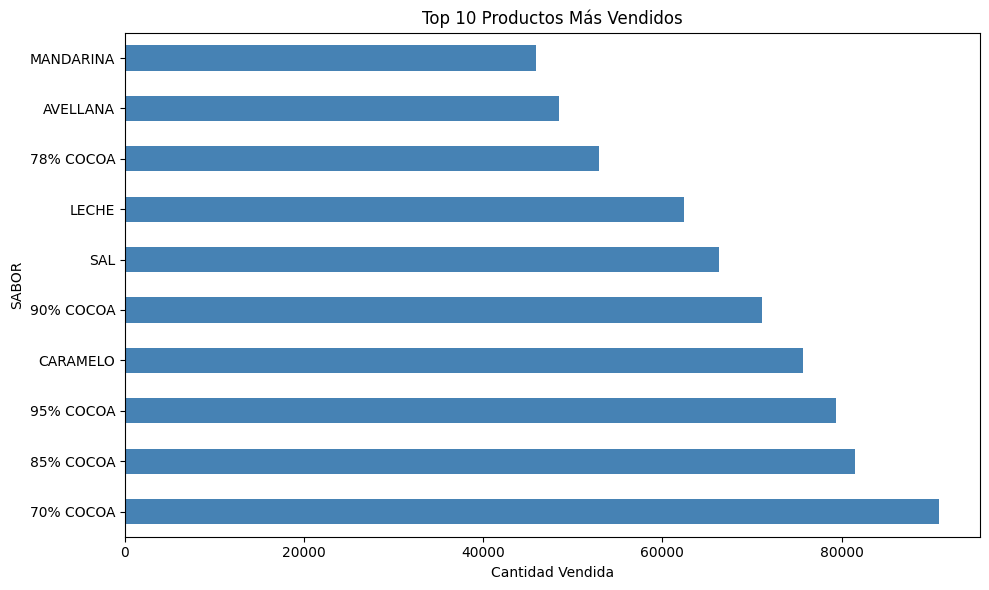

Gráfico generado y guardado como top_10_productos.png


In [13]:
top_10 = df_ventas.groupby('SABOR')['Sell Out Piezas'].sum().nlargest(10)

plt.figure(figsize=(10, 6))
top_10.plot(kind='barh', color='steelblue')
plt.title('Top 10 Productos Más Vendidos')
plt.xlabel('Cantidad Vendida')
plt.tight_layout()
plt.savefig('top_10_productos.png')
plt.show()

print("Gráfico generado y guardado como top_10_productos.png")